In [1]:
import random
# from scipy.spatial import Voronoi
from scipy.spatial import Voronoi, voronoi_plot_2d

#list of random points for this example
points = [(random.randint(0,100),random.randint(0,100)) for i in range(100)]
vor = Voronoi(points)

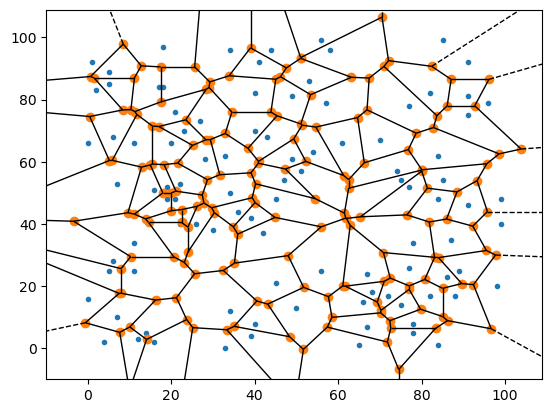

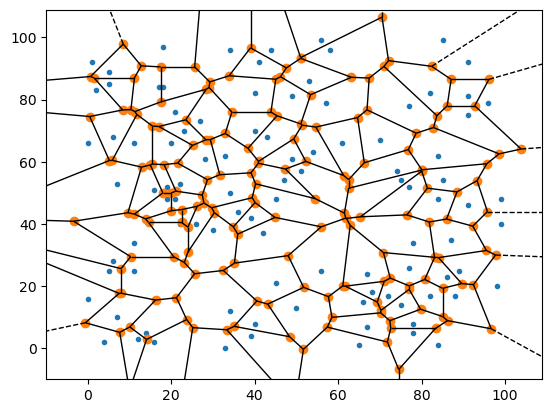

In [37]:
voronoi_plot_2d(vor)

In [9]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(Polygon(vor.vertices[region]))

In [16]:
from shapely.geometry import Polygon, Point
import geopandas as gpd

# Convert the Voronoi regions to Shapely polygons
polygons = []
for region in vor.regions:
    # if -1 not in region:
    #     polygons.append(Polygon(vor.vertices[region]))
    polygons.append(Polygon(vor.vertices[region]))

# Filter out polygons that are not within the bounding box
# bbox = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])
# polygons = [poly.intersection(bbox) for poly in polygons if poly.intersects(bbox)]

# polygons

# # Print the resulting polygons
# for poly in polygons:
#     print(poly)

<Axes: >

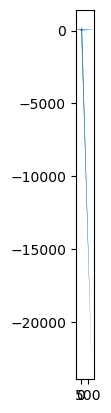

In [23]:
gpd.GeoDataFrame(geometry=polygons).plot()

# Применительно к расчетам

In [1]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
from tabulate import tabulate
import matplotlib.pyplot as plt

from shapely.geometry import Polygon, Point
from scipy.spatial import Voronoi, voronoi_plot_2d

from genesis.swiss_knife import CMAP_GrGldRd

In [26]:
G = ox.load_graphml('data/gds.ml')
buildings = gpd.read_file('data/buildings.gpkg', layer='здания')
area = gpd.read_file('data/city_borders.gpkg')  #, layer='общая граница')

In [27]:
existed_units = gpd.read_file('fire_data/units.gpkg', layer='units')
existed_units

,Наименование подразделения,Вид подразделения,Широта,Долгота,Адрес,geometry
0,8 ПСЧ 1 ПСО,ФПС,56.003588,92.943005,"\nг. Красноярск, \nул. Западная, 6",POINT (92.94300 56.00359)
1,23 ПСЧ ФПС ГПС,ФПС,56.032549,93.045988,"г. Красноярск, ул. 26 Бакинских комиссаров,1",POINT (93.04599 56.03255)
2,СПСЧ ФПС ГПС,ФПС,56.110962,92.928497,"г.Красноярск,\n ул. 40 лет Побелы, 15",POINT (92.92850 56.11096)
3,10 ПСЧ 1 ПСО,ФПС,55.975511,92.836770,"г.Красноярск,\n ул. 60 лет Октября, 2 стр. 1",POINT (92.83677 55.97551)
4,2 ПСЧ 1 ПСО,ФПС,56.021749,93.014601,"г.Красноярск, \nпр. Красноярский рабочий, 17",POINT (93.01460 56.02175)
5,3 ПСЧ 1 ПСО,ФПС,56.048379,92.772604,"г.Красноярск, \nул. Калинина, 90 А",POINT (92.77260 56.04838)
6,ОП 20 ПСЧ 1 ПСО,ФПС,55.986929,92.860818,"г.Красноярск, \nул. Карамзина, 15",POINT (92.86082 55.98693)
7,17 ПСЧ 1 ПСО,ФПС,56.066198,92.948278,"г.Красноярск, \nул. Космонавтов, 8",POINT (92.94828 56.06620)
8,19 ПСЧ 1 ПСО,ФПС,56.011092,92.819873,"г.Красноярск, \nул. Ленина, 216",POINT (92.81987 56.01109)
9,1 ПСЧ 1 ПСО,ФПС,56.013472,92.873817,"г.Красноярск, \nул. Ленина, 59",POINT (92.87382 56.01347)


In [28]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.project_gdf(nodes_gdf)
print(nodes_gdf.crs, existed_units.crs)

units = ox.project_gdf(existed_units).sjoin_nearest(nodes_gdf[['geometry']], max_distance=100)
units.rename(columns={'index_right': 'node'}, inplace=True)

units_points = {n:u for n,u in zip(units['node'], units['Наименование подразделения'])}
units_points

+proj=utm +zone=46 +ellps=WGS84 +datum=WGS84 +units=m +no_defs +type=crs EPSG:4326


{2964257101: '8 ПСЧ 1 ПСО ',
 7065906711: '23 ПСЧ ФПС ГПС ',
 6975650554: 'СПСЧ ФПС ГПС ',
 7863477992: '10 ПСЧ 1 ПСО',
 3285364967: '2 ПСЧ 1 ПСО',
 7013522763: '3 ПСЧ 1 ПСО',
 9293574019: 'ОП 20 ПСЧ 1 ПСО',
 4082373816: '17 ПСЧ 1 ПСО',
 7027868616: '19 ПСЧ 1 ПСО',
 10839566268: '1 ПСЧ 1 ПСО',
 6468642579: '20 ПСЧ 1 ПСО',
 4100024727: '4 ПСЧ 1 ПСО',
 6225811246: '5 ПСЧ 1 ПСО'}

In [29]:
buildings_nd = ox.project_gdf(buildings).sjoin_nearest(nodes_gdf[['geometry']], max_distance=100)
buildings_nd.rename(columns={'index_right': 'node'}, inplace=True)

In [30]:
import numpy as np
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding

times, nearest = FirstArrivalUnitState()(G, points=units_points)

merged_df = pd.merge(buildings_nd,
                    pd.concat([times, nearest], axis=1),
                    left_on=['node'],
                    right_index=True)

<Axes: >

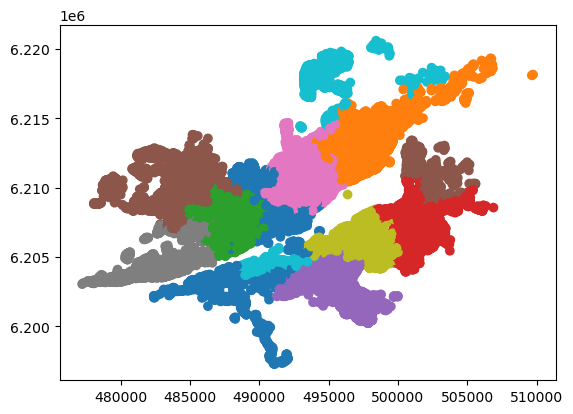

In [39]:
merged_df2 = merged_df.copy()
merged_df2['geometry'] = merged_df2.geometry.centroid
merged_df2.plot(column='nearest')

In [87]:
pnts = [(x,y) for x, y in zip(merged_df2['geometry'].x, merged_df2['geometry'].y)]
vor = Voronoi(pnts)
# voronoi_plot_2d(vor)


# Convert the Voronoi regions to Shapely polygons
polygons = []
for region in vor.regions:
    if -1 not in region:
        polygons.append(Polygon(vor.vertices[region]))
    # polygons.append(Polygon(vor.vertices[region]))

ploy_gdf = ox.project_gdf(gpd.GeoDataFrame(geometry=polygons, crs=merged_df2.crs), to_latlong=True)

In [89]:
vor_cliped = ploy_gdf.clip(area)

<Axes: >

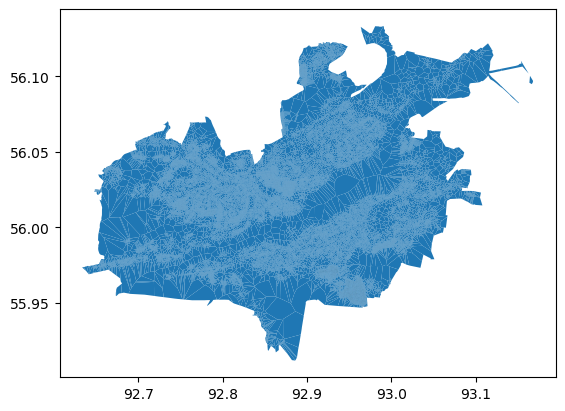

In [90]:
vor_cliped.plot()

In [101]:
merged_df3 = vor_cliped.sjoin(ox.project_gdf(merged_df2, to_latlong=True), how='inner', predicate='intersects')
merged_df3.head(2)

,geometry,index_right,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,node,times,nearest,centroids
7288,"POLYGON ((92.98920 55.95792, 92.98912 55.95902...",37264,1007668728,NaN,NaN,Дача,NaN,NaN,NaN,NaN,1807023730,16.698090,20 ПСЧ 1 ПСО,POINT (499483.078 6201444.368)
46354,"POLYGON ((92.96993 55.94840, 92.96990 55.94935...",40049,1109759173,NaN,NaN,Дача,NaN,NaN,NaN,NaN,2072428656,13.897689,20 ПСЧ 1 ПСО,POINT (498140.984 6200442.263)


<Axes: >

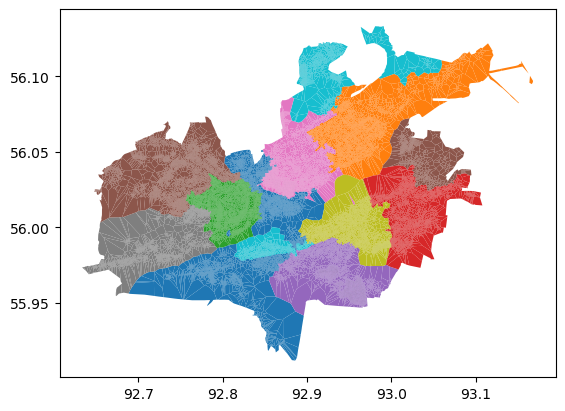

In [102]:
merged_df3.plot(column='nearest')

Формирование итоговых полигонов границ районов выезда

In [119]:
total_polys = []
total_names = []
for nearest_unit in merged_df3['nearest'].unique():
    print(nearest_unit, end='\r')
    selected = merged_df3[merged_df3['nearest'] == nearest_unit]
    total_polys.append(selected.geometry.unary_union)
    total_names.append(nearest_unit)



In [121]:
result_areas = gpd.GeoDataFrame({'name':total_names}, geometry=total_polys, crs=merged_df3.crs)
result_areas

,name,geometry
0,20 ПСЧ 1 ПСО,"POLYGON ((92.85480 55.96496, 92.85585 55.96720..."
1,2 ПСЧ 1 ПСО,"POLYGON ((92.97659 56.01629, 92.97631 56.01668..."
2,8 ПСЧ 1 ПСО,"POLYGON ((92.89995 55.98983, 92.90013 55.99011..."
3,10 ПСЧ 1 ПСО,"MULTIPOLYGON (((92.74258 55.95292, 92.73028 55..."
4,5 ПСЧ 1 ПСО,"POLYGON ((92.67117 55.96931, 92.66951 55.97000..."
5,19 ПСЧ 1 ПСО,"POLYGON ((92.76759 56.01413, 92.76706 56.01415..."
6,ОП 20 ПСЧ 1 ПСО,"MULTIPOLYGON (((92.82462 55.97811, 92.82372 55..."
7,1 ПСЧ 1 ПСО,"MULTIPOLYGON (((92.82013 56.03380, 92.82013 56..."
8,3 ПСЧ 1 ПСО,"POLYGON ((92.65685 56.00387, 92.65484 56.00327..."
9,4 ПСЧ 1 ПСО,"MULTIPOLYGON (((92.84713 56.02655, 92.84673 56..."


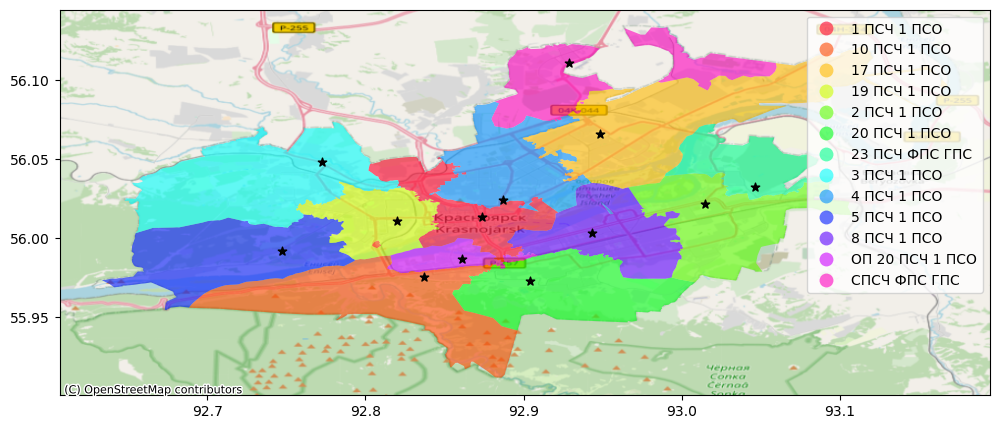

In [145]:
import contextily
import time

try_number=3
sleep_time=5

ax = result_areas.plot(column='name', legend=True, figsize=(12,12), cmap='gist_rainbow', alpha=0.6)
# existed_units.plot(ax=ax,  markersize=60, c='w')
existed_units.plot(ax=ax, marker="*", markersize=40, c='k')

map_ready=False
try_i = 1
while not map_ready:
    try:
        contextily.add_basemap(ax,
                            crs=result_areas.crs.to_string(),
                            source=contextily.providers.OpenStreetMap.DE
                            )
        map_ready=True
    except:
        print(f"Попытка №{try_i}. Получить карту не удалось.")
        try_i+=1
        if try_i>try_number:
            print(f"Получить карту за {try_number} попыток не удалось. Попробуйте выполнить запрос позже.")
            map_ready=True
        time.sleep(sleep_time)

In [128]:
result_areas.to_file('fire_data/fire_areas.gpkg', driver='GPKG')